In [ ]:
# Import basic libraries
import matplotlib.pyplot as plt
import random
import numpy as np
import torch

# set common seed for all libraries
random.seed(24)
np.random.seed(24)
torch.manual_seed(24)
torch.cuda.manual_seed_all(24)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# GMM, NADE, and VAE Comparison on MNIST

## Import data

In [ ]:
from torchvision import datasets, transforms

In [ ]:
# import MNIST test dataset
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


## Preprocess and Split Data

In [ ]:
# seperate images and labels from dataset and preprocess images
images = []
labels = []

for i in range(len(dataset)):
    image, label = dataset[i]
    # round images to map them into zero and one
    images.append(np.round(image))
    labels.append(label)

images = torch.stack(images).to(torch.float32)
labels = torch.tensor(labels)

In [ ]:
# Collect train and test dataset
X_train = images[:1000]
y_train = labels[:1000]

X_test = images[1000:2000]
y_test = labels[1000:2000]


In [ ]:
# check data type
X_train.dtype, X_test.dtype

(torch.float32, torch.float32)

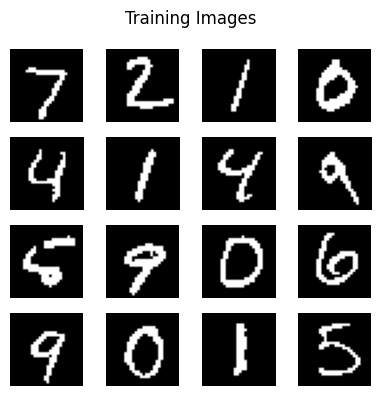

In [ ]:
# show train images
fig, axes = plt.subplots(4,4, figsize=(4,4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28,28), cmap='gray')
    ax.axis('off')

plt.suptitle('Training Images')
plt.tight_layout()
plt.show()


## Train GMM

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
# train GMM model with 10 components (dimension of laten variable z)
gmm = GaussianMixture(n_components=10, covariance_type='diag',max_iter=5000, random_state=24)
gmm.fit(X_train.view(-1,784)) # Flaten MNIST to [1000, 784]


GaussianMixture(covariance_type='diag', max_iter=5000, n_components=10,
                random_state=24)

## Generate and visualize samples from GMM

In [ ]:
# Generate 1000 samples using GMM
gmm_samples =  gmm.sample(n_samples=1000)[0]

# Randomly shuffle samples
np.random.shuffle(gmm_samples)

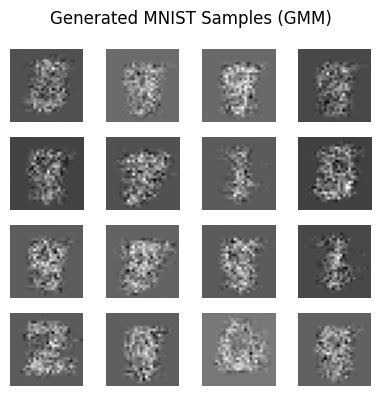

In [ ]:
# plot and show 16 samples
fig, axes = plt.subplots(4,4, figsize=(4,4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(gmm_samples[i].reshape(28,28), cmap='gray')
    ax.axis('off')

plt.suptitle('Generated MNIST Samples (GMM)')
plt.tight_layout()
plt.show()

## - Why is GMM a reasonable baseline? What are its limitations?
<div dir='rtl' align='justify'>
GMM توزیع داده‌ها رو به صورت جمعی از توزیع های گاوسی مدل میکند و در نتیجه محاسبه‌ درستنمایی ساده است و فرم بسته دارد و نمونه تولید کردن از آن هم ساده است و فرم بسته دارد. به دلیل multi-modality بودن میتواند میتواند داده هایی مثل MNIST که به خوشه های مختلف قابل تفکیک اند خوب آموزش ببیند و خوشه های مختلف رو به خد خوبی در بر بگیرد. همچنین برازش این مدل با الگوریتم EM روی مجموعه‌ نسبتا کوچک از داده ها که در اینجا 1000 نمونه است، نبت به مدل های NADE و VAE سریع است و نمونه تولید کردن یا محاسبه درستنمایی نیز با پیچیدگی محاسباتی خطی نسبت به تعداد مولفه ها و ابعاد داده ها انجام میشود و بر خلاف NADE که این کار را به صورت دنباله ای انجام میداد، GMM به صورت موازی میتواند انجام دهد و این برای مقایسه سرعت نمونه تولید کردن مدل های خیلی مهم است. همچنین از آنجایی که هم متغییر یا فضای پنهان دارد و هم تابع درستنمایی را با فرم بسته میتواند محاسبه کند، مدل مناسبی برای این است که هر خانواده ای از مدل های مولد با آن مقایسه بشود. چون همه ویژگی ها رو باهم دارد.

با این حال محدودیت های این مدل GMM که ماتریس واریانس کواریانس آن قطری فرض شده این است که فرض گوسی بودن داده ها در داده های پیچیده و دارای منیفلد غیر خطی برقرار نیست و مدل به خوبی نمیتواند این روابط رو درک کند. همچنین در فضای ۷۸۴ بعدی مانند MNIST قادر به مدلسازی همبستگی های پیکسل ها نیست  چون فرض قطری بودن ماتریس واریانس کوواریانس رو دارد و در نتیجه نمونه های تولیدی یا خیلی نرم و صاف میشوند یا پر از نویز. به تعداد مئلفه ها نیز خیلی حساس است و اگر کم باشد مدل کم برازش می‌شود و اگر زیاد هم باشد خوشه‌ ها میشود و بیش برازش میشود. در نهایت تصاویر تولید شده از وضوح و یکپارچگی معنایی خوبی برخوردار نیستند، بنابراین به عنوان معیار ارزیابی کیفیت نمونه، مدل پایه‌ ای ضعیفی محسوب میشوند.

</div>


# **Train and Save Snapshots NADE and VAE**
<div dir='rtl' align='justify'>
در این بخش مدل های NADE و VAE رو با همان کلاس های مدل تمرین های قبلی آموزش دادم و نتایج و نمونه های تولید شده از آن ها رو ذخیره کردم. در تسک های بعدی از نتایج و نمونه های تولید شده و ذخیره شده در این بخش استفاده شده.
</div>

In [ ]:
from torch import nn, optim
from torch.utils.data import DataLoader


In [ ]:
# create a DataLoader for the train set that loads X_train
train_loader = DataLoader(X_train, batch_size=64, shuffle=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Define, Initialize and Train NADE

### Defining the NADE Model

In [ ]:
# 5. NADE Model
class NADE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        """Initialize the Neural Autoregressive Density Estimation model.

        Args:
            input_dim (int): Dimension of input data (flattened image size)
            hidden_dim (int): Number of units in hidden layer
        """
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.W = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))
        self.V = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(input_dim))

        # Training metadata
        self.start_epoch = 0
        self.best_loss = float('inf')
        self.train_history = []
        self.test_history = []

    def forward(self, x):
        """Forward pass through the NADE model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            tuple: (x_hat, all_h) where:
                x_hat: reconstructed probabilities for each dimension
                all_h: all hidden states during autoregressive process
        """
        batch_size = x.size(0)
        x_hat = torch.zeros_like(x)
        all_h = []
        for d in range(self.input_dim):
            # Compute pre-activation for dimension d:
            a_d = self.c +  torch.matmul(x[:, :d], self.W[:d])
            h_d = torch.sigmoid(a_d)
            # Compute output probability for dimension d:
            p_d = torch.sigmoid(self.b[d] + torch.matmul(h_d, self.V[:, d]))
            x_hat[:, d] = p_d
            all_h.append(h_d)
        return x_hat, torch.stack(all_h, dim=1)

    def log_prob(self, x):
        """Compute log probability of input samples under the model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            torch.Tensor: Log probabilities for each sample (batch_size)
        """
        x_hat, _ = self.forward(x)
        # Compute Bernoulli log likelihood:
        log_prob = x * torch.log(x_hat + 1e-6) + (1 - x) * torch.log(1 - x_hat + 1e-6)


        # Sum over all dimensions (input_dim)
        return log_prob.sum(dim=1)


    def generate_samples(self, num_samples=10):
        """
        Generates new images via ancestral sampling
        Args:
            num_samples: How many images to generate
        Returns:
            Tensor of shape (num_samples, input_dim)
        """
        samples = torch.zeros(num_samples, 784).to(device)
        with torch.no_grad():
            for d in range(784):
                p_d = self.forward(samples)[0][:, d]
                samples[:, d] = torch.bernoulli(p_d)
        return samples.cpu()

### Initialize and Train NADE
Train and save checkpoints, losses, and samples per each 5 epochs

In [ ]:
#Initialize NADE model and optimizer
NADE_model = NADE().to(device)
optimizer = optim.Adam(NADE_model.parameters(), lr=1e-4)

In [ ]:
import os
import time

In [ ]:
num_epochs = 250
snapshot_interval = 5
num_samples = 1000

#Base drive path
base_path = "/content/drive/MyDrive/experiments/mnist_nade"
ckpt_path = os.path.join(base_path, "checkpoints") #path for checkpoints
sample_path = os.path.join(base_path, "samples") #path for generated samples
log_path = os.path.join(base_path, "logs") #Path for useful information (epoch number, loss, etc.)
for d in (ckpt_path, sample_path, log_path):
    os.makedirs(d, exist_ok=True)

log_path = os.path.join(log_path, "training_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,elapsed_time_s,train_loss,peak_mem_MB,avg_mem_MB\n")

#Training loop
for epoch in range(1, num_epochs + 1):

    start_time = time.time()
    NADE_model.train()
    epoch_loss = 0
    mem_accum = 0

    torch.cuda.reset_peak_memory_stats(device)
    for batch in train_loader:
        batch = batch.view(-1, 784).to(device)
        optimizer.zero_grad()
        loss = -NADE_model.log_prob(batch).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        mem_accum += torch.cuda.memory_allocated(device)

    avg_loss = epoch_loss/len(train_loader)
    elapsed = time.time()-start_time  #Training time for epoch

    # compute memory metrics
    peak_mem = torch.cuda.max_memory_allocated(device)/1e6   #GPU memory usage (peak)
    avg_mem  = (mem_accum/len(train_loader))/1e6   #GPU memory usage (average)

    # Save log metrics
    with open(log_path, "a") as f:
        f.write(f"{epoch},{elapsed:.2f},{avg_loss:.6f},"f"{peak_mem:.1f},{avg_mem:.1f}\n")

    print(f"Epoch {epoch}/{num_epochs}, Loss={avg_loss:.4f}, "
          f"PeakMem={peak_mem:.1f}MB, AvgMem={avg_mem:.1f}MB")

    # Save model's checkpoint and samples in snapshot
    if epoch%snapshot_interval == 0:
        # Save checkpoint
        torch.save(NADE_model.state_dict(),
                   os.path.join(ckpt_path, f"nade_epoch{epoch:03d}.pt"))
        # Generate 1000 samples
        NADE_model.eval()
        with torch.no_grad():
            samples = NADE_model.generate_samples(num_samples).numpy()
        # save samples
        np.save(os.path.join(sample_path, f"nade_epoch{epoch:03d}.npy"), samples)

print("Training complete.")


Epoch 1/250, Loss=492.8068, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 2/250, Loss=400.0005, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 3/250, Loss=334.3541, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 4/250, Loss=291.3392, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 5/250, Loss=264.3274, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 6/250, Loss=247.0351, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 7/250, Loss=236.1717, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 8/250, Loss=228.4770, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 9/250, Loss=223.2267, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 10/250, Loss=218.8982, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 11/250, Loss=216.1468, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 12/250, Loss=213.4685, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 13/250, Loss=211.3919, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 14/250, Loss=210.1621, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 15/250, Loss=208.7683, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 16/250, Loss=207.5128, PeakMem=235.1MB, AvgMem=30.8MB
Epoch 17/250, Loss=206.5141, PeakMem=235.1MB, Avg

## Define, Initialize and Train VAE

### Defining the VAE Model

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
        )
        self.mu = nn.Linear(400, latent_dim)
        self.log_var = nn.Linear(400, latent_dim)

    def forward(self, x):
        h = self.enc(x)
        return self.mu(h), self.log_var(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.dec(z)

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):

        std = torch.exp(0.5*log_var)
        eps = torch.normal(mean=0,std=1,size=mu.shape).to(std.device)
        return mu+eps*std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x, mu, log_var


In [ ]:
def vae_loss(recon_x, x, mu, log_var):

    # Reconstruction Loss:
    recon_loss=nn.functional.mse_loss(recon_x,x,reduction='sum')

    # KL Divergence Loss:
    kl_loss=-0.5*torch.sum(1 +log_var-mu.pow(2)-log_var.exp())

    # Total loss combines both terms
    loss = recon_loss + kl_loss

    return loss, recon_loss, kl_loss


### Initialize and Train VAE
Train and save checkpoints, losses, and samples per each 5 epochs

In [ ]:
#Initialize NADE model and optimizer
VAE_model = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(VAE_model.parameters(), lr=1e-3)

In [ ]:
import os
import time

In [ ]:
num_epochs = 250
snapshot_interval = 5
num_samples = 1000    # samples per snapshot

#Base drive path
base_path = "/content/drive/MyDrive/experiments/mnist_vae"
ckpt_path = os.path.join(base_path, "checkpoints") # path for checkpoints
sample_path = os.path.join(base_path, "samples") # path for generated samples
log_path = os.path.join(base_path, "logs") # Path for useful information (epoch number, loss, etc.)

for d in (ckpt_path, sample_path, log_path):
    os.makedirs(d, exist_ok=True)

log_path = os.path.join(log_path, "training_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,elapsed_time_s,train_loss,recon_loss,kl_loss,peak_mem_MB,avg_mem_MB\n")

# Training loop
for epoch in range(1, num_epochs + 1):

    start_time = time.time()

    VAE_model.train()

    sum_loss = 0
    sum_recon = 0
    sum_kl = 0
    mem_accum = 0

    torch.cuda.reset_peak_memory_stats(device)

    for x in train_loader:

        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()

        recon_x, mu, log_var = VAE_model(x)
        loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, log_var)

        loss.backward()
        optimizer.step()

        sum_loss += loss.item()
        sum_recon += recon_loss.item()
        sum_kl += kl_loss.item()
        mem_accum += torch.cuda.memory_allocated(device)

    avg_loss  = sum_loss/len(train_loader) # Total loss
    avg_recon = sum_recon/len(train_loader) # reconstruction loss
    avg_kl = sum_kl/len(train_loader) # KL loss

    elapsed = time.time() - start_time # Training time

    peak_mem = torch.cuda.max_memory_allocated(device)/1e6    #GPU memory usage (peak)
    avg_mem  = (mem_accum/len(train_loader))/1e6   #GPU memory usage (average)

    # Save log metrics
    with open(log_path, "a") as f:
        f.write(f"{epoch},{elapsed:.2f},{avg_loss:.6f},"f"{avg_recon:.6f},{avg_kl:.6f},"f"{peak_mem:.1f},{avg_mem:.1f}\n")

    print(f"Epoch {epoch}/{num_epochs}: "
          f"Loss={avg_loss:.4f}, Recon={avg_recon:.4f}, KL={avg_kl:.4f}, "
          f"PeakMem={peak_mem:.1f}MB, AvgMem={avg_mem:.1f}MB")

    # Save model's checkpoint and samples in snapshot
    if epoch % snapshot_interval == 0:
        # Save checkpoint
        torch.save(VAE_model.state_dict(),
                   os.path.join(ckpt_path, f"vae_epoch{epoch:03d}.pt"))

        # Generate 1000 samples
        VAE_model.eval()
        with torch.no_grad():
             z = torch.randn(num_samples, VAE_model.encoder.mu.out_features).to(device)
             samples = VAE_model.decoder(z).cpu().detach().numpy()
        # save samples
        np.save(os.path.join(sample_path, f"vae_epoch{epoch:03d}.npy"), samples)

print("Training complete.")


Epoch 1/250: Loss=7339.0477, Recon=6943.0968, KL=395.9509, PeakMem=46.1MB, AvgMem=43.6MB
Epoch 2/250: Loss=4578.9283, Recon=4318.2456, KL=260.6827, PeakMem=46.1MB, AvgMem=43.6MB
Epoch 3/250: Loss=4296.0321, Recon=4127.3927, KL=168.6394, PeakMem=41.1MB, AvgMem=38.5MB
Epoch 4/250: Loss=4185.4844, Recon=4037.6302, KL=147.8541, PeakMem=41.1MB, AvgMem=38.5MB
Epoch 5/250: Loss=4090.0093, Recon=3942.6356, KL=147.3738, PeakMem=41.1MB, AvgMem=38.5MB
Epoch 6/250: Loss=3950.3076, Recon=3773.9711, KL=176.3364, PeakMem=41.3MB, AvgMem=38.8MB
Epoch 7/250: Loss=3853.4245, Recon=3652.1957, KL=201.2288, PeakMem=41.3MB, AvgMem=38.8MB
Epoch 8/250: Loss=3778.7429, Recon=3579.8812, KL=198.8617, PeakMem=41.3MB, AvgMem=38.7MB
Epoch 9/250: Loss=3724.6196, Recon=3531.5857, KL=193.0338, PeakMem=41.1MB, AvgMem=38.5MB
Epoch 10/250: Loss=3687.0758, Recon=3493.4902, KL=193.5856, PeakMem=41.1MB, AvgMem=38.5MB
Epoch 11/250: Loss=3659.4603, Recon=3467.4576, KL=192.0028, PeakMem=41.3MB, AvgMem=38.6MB
Epoch 12/250: Loss=

# **Task 2: Model Verification**


## - Generate 1,000 samples (using identical random seeds) for both NADE and VAE.

In [ ]:
# load last epoch generated samples for NADE
final_nade_samples = np.load('/content/drive/MyDrive/experiments/mnist_nade/samples/nade_epoch250.npy')

# In case you want to generate sample again
## Load saved NADE model
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#NADE_model = NADE()
#if torch.cuda.is_available():
#  NADE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_nade/checkpoints/nade_epoch250.pt'))
#else:
#  NADE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_nade/checkpoints/nade_epoch250.pt',map_location=torch.device('cpu')))
#NADE_model.to(device)
#NADE_model.eval()

## Generate 1000 sample from final NADE
#final_nade_samples = NADE_model.generate_samples(1000).cpu().numpy()



In [ ]:
# load last epoch generated samples for NADE
final_vae_samples = np.load('/content/drive/MyDrive/experiments/mnist_vae/samples/vae_epoch250.npy')

### In case you want to generate sample again
# Load saved VAE model
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#VAE_model = VAE(latent_dim=2)
#if torch.cuda.is_available():
#    VAE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_vae/checkpoints/vae_epoch250.pt'))
#else:
#    VAE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_vae/checkpoints/vae_epoch250.pt',map_location=torch.device('cpu')))
#VAE_model.to(device)
#VAE_model.eval()

# Generate 1000 sample from final VAE
#z = torch.randn(1000, VAE_model.encoder.mu.out_features,).to(device)
#final_vae_samples = np.round(VAE_model.decoder(z).cpu().detach().numpy())

## - Manually inspect 10 random samples from each model

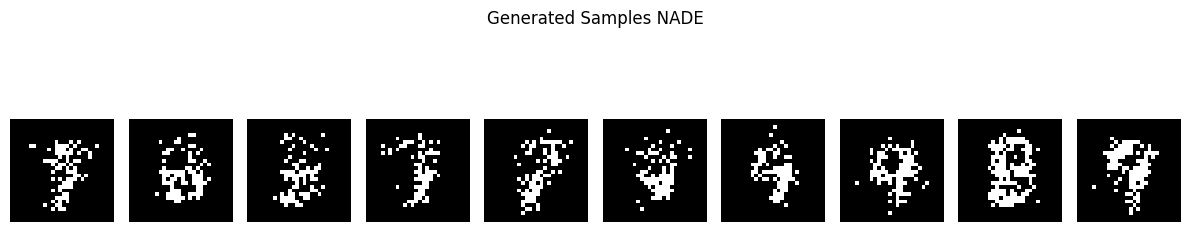

In [ ]:
# Randomly choose 10 sample from NADE model and visualize
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(final_nade_samples[torch.randperm(len(final_nade_samples))[:10]][i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples NADE")
plt.tight_layout()
plt.show()

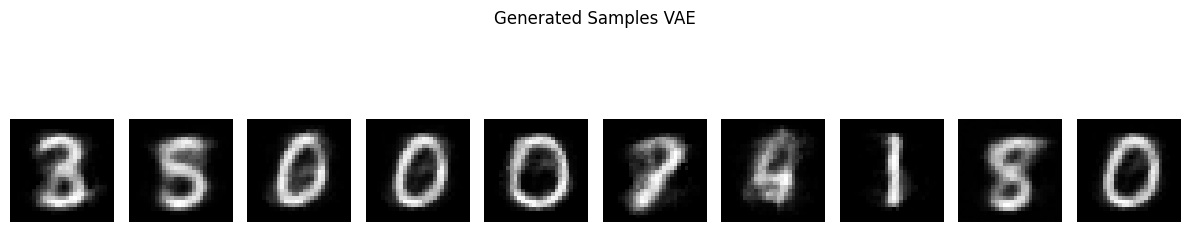

In [ ]:
# Randomly choose 10 sample from VAE model and visualize
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(final_vae_samples[torch.randperm(len(final_nade_samples))[:10]][i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples VAE")
plt.tight_layout()
plt.show()

##  - Are digits recognizable?

<div dir='rtl' align='justify'>
در نمونه های تولید شده از NADE نمونه ها تا حدی قابل تشخیص هستند و شکل کلی ارقام حفظ شده است. با این حال در برخی موارد تصاویر بسیار نویزی و شکل خاصی ندارند یا لبه ها بسیار پراکنده و نویزی هستند. مثل اعداد 0 و 9

در نمونه های تولید شده از VAE بیشتر ارقام واضح و خوانا هستند. حلقه‌ها و خطوط اصلی یکپارچه هستند. ولی چند نمونه وجود دارد که به دلیل تار بودن بیش از حد یا ترکیبی به نظر رسیدن، تشخیصشان کمی دشوار است.
</div>

##  - Any systematic artifacts (e.g., blurry VAE samples, NADE pixel noise)?

<div dir='rtl' align='justify'>

* NADE :      
  - چون NADE تصاویر رو به صورت دنباله  ای و پیکسل به پیکسل تولید میکند، در بعضی جاها نقاط ریز سیاه یا سفید به صورت نویزی ایجاد شده است. یا مثلا برش های غیر عادی ای ایجاد شده.
  - در بعضی نمونه‌ها بخش هایی از تصویر کاملا خراب تولید شده اند. مدل وسط تولید پیکسل ها به مسیر اشتباهی می‌افتد و نتیجه نهایی نویزی و غیرقابل تشخیص است.
  - در بعضی نمونه ها عدد ها ناقص هستند و یا بخشی از آن مشخص نیست

*   VAE :       

  - تصاویر به دلیل اینکه مدل نمیتواند مقدار دقیق Likelihood رو بدست بیارد و کران پایین آن را تخمین میزند، بلوری و تار هستند و مرز ها و جزییات تار شده.
  - بعضی جزییات ریز از دست رفته است و خطوط نازک به‌شکل ضخیم یا گرد درآمده اند.
  - برخلاف NADE، پیکسل های پراکنده دیده نمیشود و تمام تار و بلوری بودن به صورت یکنواخت در تصویر پخش شده است.

</div>


# **Task 3: Sample Quality Metrics**

## Load LeNet

In [ ]:
# clone pre-trained LeNet for the MNIST dataset from GitHub
!git clone https://github.com/csinva/gan-vae-pretrained-pytorch.git
!cd gan-vae-pretrained-pytorch

Cloning into 'gan-vae-pretrained-pytorch'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 193 (delta 0), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (193/193), 100.76 MiB | 22.93 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [ ]:
import torch.nn as nn
from collections import OrderedDict

In [ ]:
# Copied the LeNet model class from its GitHub repository
class LeNet5(nn.Module):
    """
    Input - 1x32x32
    C1 - 6@28x28 (5x5 kernel)
    tanh
    S2 - 6@14x14 (2x2 kernel, stride 2) Subsampling
    C3 - 16@10x10 (5x5 kernel, complicated shit)
    tanh
    S4 - 16@5x5 (2x2 kernel, stride 2) Subsampling
    C5 - 120@1x1 (5x5 kernel)
    F6 - 84
    tanh
    F7 - 10 (Output)
    """
    def __init__(self):
        super(LeNet5, self).__init__()

        self.convnet = nn.Sequential(OrderedDict([
            ('c1', nn.Conv2d(1, 6, kernel_size=(5, 5))),
            ('relu1', nn.ReLU()),
            ('s2', nn.MaxPool2d(kernel_size=(2, 2), stride=2)),
            ('c3', nn.Conv2d(6, 16, kernel_size=(5, 5))),
            ('relu3', nn.ReLU()),
            ('s4', nn.MaxPool2d(kernel_size=(2, 2), stride=2)),
            ('c5', nn.Conv2d(16, 120, kernel_size=(5, 5))),
            ('relu5', nn.ReLU())
        ]))

        self.fc = nn.Sequential(OrderedDict([
            ('f6', nn.Linear(120, 84)),
            ('relu6', nn.ReLU()),
            ('f7', nn.Linear(84, 10)),
            ('sig7', nn.LogSoftmax(dim=-1) )
        ]))

    def forward(self, img):
        output = self.convnet(img)
        output = output.view(img.size(0), -1)
        output = self.fc(output)
        return output

In [ ]:
# Load the model weights from the cloned repository
net = LeNet5().eval()
net.load_state_dict(torch.load('/content/gan-vae-pretrained-pytorch/mnist_classifier/weights/lenet_epoch=12_test_acc=0.991.pth'))


<All keys matched successfully>

In [ ]:
import torch.nn.functional as F

In [ ]:
# Pad the train image to 32x32
padded_input = F.pad(X_train, (2, 2, 2, 2), "constant", 0)

# Evaluate model on train dataset
preds = net(padded_input).detach().numpy()
class_preds = np.argmax(preds, axis=1)
print('test acc', sum(class_preds == y_train) / 1000)

test acc tensor(0.9800)


In [ ]:
# Pad the test image to 32x32
padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

# Evaluate model on test dataset
preds = net(padded_input).cpu().detach().numpy()
class_preds = np.argmax(preds, axis=1)
print('test acc', sum(class_preds == y_test) / len(y_test))

test acc tensor(0.9770)


## Metrics Calculation

In [ ]:
def inception_score(X, classifier):
    # check if data is tensor
    X = torch.as_tensor(X, dtype=torch.float32)
    # pad input to match LeNet dimension
    padded_input = F.pad(X.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)

    # get classes probabilities
    probs = torch.exp(classifier(padded_input)) # LeNet output is logSoftmax
    # LeNet outputs which is log probabilities
    log_probs = classifier(padded_input)

    # Compute sharpness
    sharpness = torch.exp(torch.mean(torch.sum(probs*log_probs, dim=1))).item()

    # compute diversity
    c_y = torch.mean(probs,dim=0)
    diversity = torch.exp(-torch.mean(torch.matmul(probs, torch.log(c_y+1e-6)))).item()

    # Inception Score
    IS = diversity * sharpness

    return round(sharpness,3), round(diversity,3), round(IS,3)

In [ ]:
from scipy.linalg import sqrtm
from scipy.stats import multivariate_normal

In [ ]:
# function for extract feature from LeNet
def LeNetFeatureExtractor(img, model=net):

        output = model.convnet(img)
        output = output.view(img.size(0), -1)
        output = model.fc[:3](output)

        return output

In [ ]:
def fid_score(X_test, X_generated,feature_extractor):
    # check if data is tensor
    X_generated = torch.as_tensor(X_generated, dtype=torch.float32)

    # Pad generated and test datasets for LeNet
    fake_padded_input = F.pad(X_generated.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)
    real_padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

    # Extact features (using prefinal layer of LeNet)
    fake_input = feature_extractor(fake_padded_input).detach().numpy()
    real_input = feature_extractor(real_padded_input).detach().numpy()

    # Fit gaussian distribution
    mu_fake, sigma_fake = multivariate_normal.fit(fake_input)
    mu_real, sigma_real = multivariate_normal.fit(real_input)
    mu_diff = mu_real - mu_fake

    # Compute (sigma_real*sigma_fake)^1/2
    covmean = sqrtm(sigma_real.dot(sigma_fake))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # compute FID score
    fid = mu_diff.dot(mu_diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return round(fid.item(),3)

In [ ]:
from sklearn.metrics.pairwise import polynomial_kernel

In [ ]:
def kid_score(X_test, X_generated,feature_extractor,degree=2, gamma=0.1):

    # check if data is tensor
    X_generated = torch.as_tensor(X_generated, dtype=torch.float32)

    # Pad generated and test datasets for LeNet
    fake_padded_input = F.pad(X_generated.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)
    real_padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

    # Extact features (using prefinal layer of LeNet)
    fake_input = feature_extractor(fake_padded_input).detach().numpy()
    real_input = feature_extractor(real_padded_input).detach().numpy()

    m = real_input.shape[0]
    n = fake_input.shape[0]

    # Comput similarity matices
    Kxx = polynomial_kernel(real_input, real_input, degree=degree, gamma=gamma)
    Kyy = polynomial_kernel(fake_input, fake_input, degree=degree, gamma=gamma)
    Kxy = polynomial_kernel(real_input, fake_input, degree=degree, gamma=gamma)

    # fill Kxx and Kyy diagonals with zero because we don't care about each samples similarity by itself
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)

    mmd = (Kxx.sum() / (m * (m - 1)) #divide by the number of off-diagonal pairs
            + Kyy.sum() / (n * (n - 1))  #divide by the number of off-diagonal pairs
            -  2*Kxy.mean())
    return round(float(mmd),3)

In [ ]:
import pandas as pd

In [ ]:
# compute and organize metrics for all three models
metrics = {'IS':[inception_score(gmm_samples,net)[-1],
                 inception_score(final_nade_samples,net)[-1],
                 inception_score(final_vae_samples,net)[-1]],
           'FID':[fid_score(X_test, gmm_samples,LeNetFeatureExtractor),
                  fid_score(X_test, final_nade_samples,LeNetFeatureExtractor),
                  fid_score(X_test, final_vae_samples,LeNetFeatureExtractor)],
           'KID':[kid_score(X_test, gmm_samples,LeNetFeatureExtractor),
                  kid_score(X_test, final_nade_samples,LeNetFeatureExtractor),
                  kid_score(X_test, final_vae_samples,LeNetFeatureExtractor)]}
metrics = pd.DataFrame(metrics,index=['GMM','NADE','VAE'])

In [ ]:
print('Results:')
metrics

Results:


,IS,FID,KID
GMM,4.760,208.392,517.162
NADE,4.389,181.151,422.694
VAE,7.240,110.359,318.398


## - Which model scores best on each?

|index|IS|FID|KID|
|---|---|---|---|
|GMM|4\.76|208\.392|517\.162|
|NADE|4\.389|181\.151|422\.694|
|VAE|7\.24|110\.359|318\.398|

 <div dir='rtl' align='justify'>
در میان هر سه معیار، مدل VAE  بهترین عملکرد رو داشته:

- از نظر معیار IS که هر چه بیشتر باشد بهتر است، مدل امتیاز VAE برابر با 7.24 است که  بالاتر از امتیاز های NADE و GMM است.

- از نظر معیار FID که هرچه کمتر باشد بهتر است نیز، مدل VAE با اختلاف از NADE و GMM کمتر است و مقدار 110.359 را دارد.

- در معیار KID برای محاسبه kernel از polynomial درجه 2 با پارامتر گاما 0.1 استفاده شده.مقدار این معیار برای یک مدل هرچه کمتر باشد بهتر است و امتیاز مدل VAE نیز  کمتر از دو مدل NADE و GMM است و مقدار 318.398 رو دارد.

به طور کلی مدل VAE از نظر همه معیار ها با اختلاف خوبی از دو مدل دیگر بهتر عمل کرده. همچنین مدل NADE و GMM عملکرد های مشابه و امتیاز های نزدیک به هم داشتند. البته که مدل NADE با مقدار کمی از مدل GMM بهتر بوده.
</div>

## - Does this match your qualitative observations?

<div dir='rtl' align='justify'>
در مورد برتری مدل VAE این رتبه با برسی کیفی ما مطابقت دارد. اما در مورد برتری مدل NADE از GMM از نظر رتبه بندی، این با بررسی کیفی ما همخوانی ندارد. نمونه های تولید شده با VAE با وجود بلوری بودن همچنان با وضوح بهتری رقم ها در آن مشخص بودند. اما نمونه های تولید شده از NADE بسیار نویزی بودند و حتی از تصاویر نویزی GMM نیز غیر قابل تشخیص تر بودند. تصاویر GMM نیز نویزی و حالت مات داشند و تصاویر تولید شده از VAE با وجود بلوری بودن از آنها بهتر بودند. پس رتبه اول بودن VAE همخوان بود ولی برتری NADE از GMM خیر.
</div>

# **Task 4: Diversity & Sparsity**

In [ ]:
diversity_sharpness = {'Diversity': [inception_score(gmm_samples,net)[1],
                              inception_score(final_nade_samples,net)[1],
                              inception_score(final_vae_samples,net)[1]],
                        'Sharpness': [inception_score(gmm_samples,net)[0],
                              inception_score(final_nade_samples,net)[0],
                              inception_score(final_vae_samples,net)[0]]}
diversity_sharpness = pd.DataFrame(diversity_sharpness,index=['GMM','NADE','VAE'])

In [ ]:
diversity_sharpness

,Diversity,Sharpness
GMM,8.647,0.550
NADE,7.812,0.562
VAE,9.762,0.742


## - Does either model produce "conservative" digits (low diversity) or "risky" outliers?
 <div dir='rtl' align='justify'>
conservative digits به این مفهوم بر میگردد که بعضی اوقات مدل تمایل دارد نمونه هایی که تولید آن آسان تر است و یا به توزیع داده آموزشی نزدیک تر است تولید کند. مثلا در داده MNIST ممکن است در داده آموزشی زیاد باشد و مثلا عدد دیگر مثل 3 کمتر باشد و مدل بیشتر 1 تولید میکند چون یادگیری و تولید 3 هزینه بیشتری دارد. به این نمونه ها conservative digits میگویند و این وقتی رخ میدهد که diversity پایین باشد.

همجنین بعضی اوقات مدل ممکن است نمونه هایی تولید کند که ترکیبی از چند کلاس اند مثلا ترکیبی از 6 و9 ولی هیچکدام از اینها نیست یا نمونه هایی تولید کند که مشابه ان در دیتای آموزشی نبوده مثلا دست خطی که تا حالا در دیتا نبوده. یا مثلا داده ای که تناسب اجزا در ان رعایت نشده. این مفهوم به داده های risky outliers اشاره دارد و زمانی رخ میدهد که sharpness مدل کم باشد. اگر sharpness زیاد باشد، احتمال وجود این داده ها کمتر میشود چون sharpness میسنجد که نمونه های تولید شده چقدر واقعی اند و کیفیت دارند.


با توجه مقادیر Diversity و Sharpness، مدل NADE کمترین Diversity را با ۷.۸۱۲ دارد و ارقام conservative تولید میکند. به این معنی که تمایل دارد مجموعه محدودتری از کلاس های ارقام را تولید کند. مدل GMM، با Divesity متوسط ۸.۶۴۷ اما کمترین Sharpness ۰.۵۵۰، پر ریسک ترین مدل است چون طیف نسبتا خوبی از ارقام را پوشش میدهد، اما اغلب نمونه های مبهم یا نامشخص (risky outliers) تولید میکند پس ممکن است چون متنوع است ولی وضوح پایینی دارد این بین outlier ها را تولید کرده باشد. در مقابل، VAE هم بالاترین Deversity و Sharpness را دارد که نشان میدهد طیف گسترده‌ای از ارقام واضح را تولید میکند و بنابراین بهترین تعادل را برقرار می‌کند.
</div>

# **Task 5: Likelihood & Reconstruction**

In [ ]:
# create a DataLoader for the test set that loads X_test
test_loader = DataLoader(X_test, batch_size=64, shuffle=True)

## - For NADE: Report **test-set log-likelihood (bits/dim).


In [ ]:
# Load saved NADE model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NADE_model = NADE()

# If you use GPU
if torch.cuda.is_available():
  NADE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_nade/checkpoints/nade_epoch250.pt'))

# If you use CPU
else:
  NADE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_nade/checkpoints/nade_epoch250.pt',map_location=torch.device('cpu')))

NADE_model.to(device)
NADE_model.eval()

# copute test log likelihood
test_log_likelihood = 0.0
num_samples = 0

with torch.no_grad():
    for batch in test_loader:
          batch = batch.view(-1, 784).to(device)
          test_log_likelihood += NADE_model.log_prob(batch).mean().item()

    test_log_likelihood = test_log_likelihood/len(test_loader)




In [ ]:
D = 784

# normalize the test log likelihood to bits/dim format
bits_per_dim = -test_log_likelihood/(D*np.log(2))

print(f"NADE test log-likelihood: {test_log_likelihood:.4f} nats/sample")
print(f"NADE bits/dim: {bits_per_dim:.4f}")


NADE test log-likelihood: -127.6304 nats/sample
NADE bits/dim: 0.2349


## - For VAE: Report test-set ELBO.

In [ ]:
# Load saved NADE model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VAE_model = VAE(latent_dim=2)

# If you use GPU
if torch.cuda.is_available():
    VAE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_vae/checkpoints/vae_epoch250.pt'))

# If you use CPU
else:
    VAE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_vae/checkpoints/vae_epoch250.pt',map_location=torch.device('cpu')))
VAE_model.to(device)
VAE_model.eval()

# Compute test ELBO
test_elbo = 0.0
with torch.no_grad():
    for x in test_loader:
        x = x.view(-1, 784).to(device)
        recon_x, mu, log_var = VAE_model(x)
        loss, _, _ = vae_loss(recon_x, x, mu, log_var)
        # loss is -ELBO so ELBO is -loss
        test_elbo += (-loss).mean().item()
    test_elbo = test_elbo/len(test_loader)


In [ ]:
print(f"VAE test-set ELBO: {test_elbo:.4f} nats/sample")

VAE test-set ELBO: -3463.9178 nats/sample


## - Why can’t we directly compare these values?
 <div dir='rtl' align='justify'>
لگاریتم درستنمایی مجموعه تست مدل NADE بر حسب bits/dim، مقدار دقیق لگاریتم احتمال داده ها تحت مدل اتورگرسیو است. درحالی که ELBO مربوط به VAE یک کران پایین برای مقدار واقعی لگاریتم درستنمایی است که بر حسب لگاریتم e است و همواره کوچکتر و مساوی مقدار دقیق لگاریتم درستنمایی است. از آنجایی که آنها اهداف متفاوتی را بهینه میکنند (لگاریتم درستنمایی در مقابل حد پایین آن) و از واحد های مختلفی نیز استفاده میکنند، مقادیر عددی آنها در مقیاس های ناسازگاری قرار میگیرند و نمیتوان آنها رو مقایسه کرد.

هرچند مقدار دقیق لگاریتم درستنمایی در NADE در مقیاس لگاریتم e از ELBO در VAE بالاتر است ولی چون ELBO یک حد پایین است، ممکن است اختلاف ELBO از لگاریتم درستنمایی واقعی مدل VAE زیاد بوده باشد و اگر آن را میدانستیم مقدار دقیق درستنمایی VAE از NADE بهتر میبود. البته این در حد حدس است و این حدس به این دلیل است که مدل VAE در معیار های بخش قبل عملکرد خوبی داشته است. هرچند که مقدار درستنمایی بهتر لزوما به معنی نمونه های تولید شده بهتر نیست پس این حدس لزوما درست نیست و حتی ممکن است لگاریتم درستنمایی VAE از NADE کمتر بوده باشد. به هر حال از طریق مقایسه ELBO با مقدار دقیق لگاریتم درستنمایی NADE نمیتوان این رو گفت مگر اینکه ELBO از لگاریتم درستنمایی NADE بالاتر میبود در آن حالت میشد گفت حتما لگاریتم درستنمایی VAE از NADE بالاتر بوده که کران پایین آن نیز بالاتر است گه اینچا این مسئله صادق نیست و نمیتوان نظر قطعی داد.

</div>

## - What do they measure differently?
 <div dir='rtl' align='justify'>

 در مدل NADE،  معیار لگاریتم درستنمایی با مقیاس bits/dim نشان میدهد احتمال رخداد هر ویژگی  تحت توزیع شرطی چقدر است. در حالی که ELBO در VAE از جمع خطای بازسازی و KL است و یک کران پایین برای لگاریتم درستنمایی است و همواره کوچکتر مساوی آن است.
</div>

# **Task 6: Training Efficiency**


## - FID vs. epoch (for NADE and VAE).

In [ ]:
import pandas as pd
import os

In [ ]:
# Define paths
nade_samples_path = '/content/drive/MyDrive/experiments/mnist_nade/samples'
vae_samples_path  = '/content/drive/MyDrive/experiments/mnist_vae/samples'

# Compute FID per snapshots for NADE
nade_fid = []
for epoch in range(5,255,5):

    samples = np.load(os.path.join(nade_samples_path, f"nade_epoch{epoch:03d}.npy")) # load samples for specified ecpoch
    fid_val = fid_score(X_test, samples, LeNetFeatureExtractor) # compute FID score for samples
    nade_fid.append({'epoch': epoch, 'FID': fid_val})

nade_fid_df = pd.DataFrame(nade_fid).sort_values('epoch')

# Compute FID snapshots for VAE
vae_fid = []
for epoch in range(5,255,5):

    samples = np.load(os.path.join(vae_samples_path, f"vae_epoch{epoch:03d}.npy")) # load samples for specified ecpoch
    fid_val = fid_score(X_test, samples, LeNetFeatureExtractor) # compute FID score for samples
    vae_fid.append({'epoch': epoch, 'FID': fid_val})

vae_fid_df = pd.DataFrame(vae_fid).sort_values('epoch')


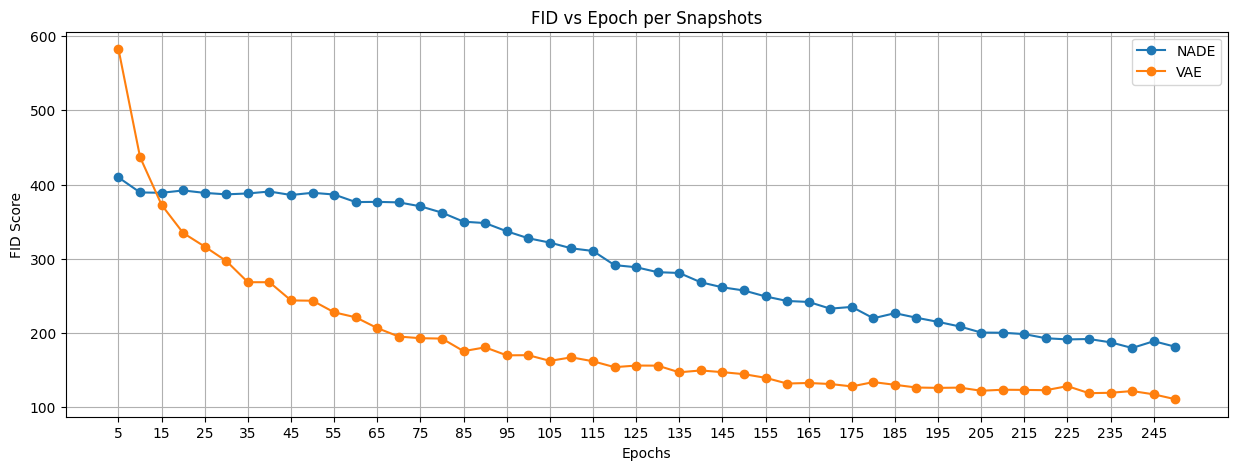

In [ ]:
# Plot FID vs epoch
plt.figure(figsize=(15, 5))

plt.plot(nade_fid_df['epoch'], nade_fid_df['FID'], 'o-',label="NADE")
plt.plot( vae_fid_df['epoch'], vae_fid_df['FID'], 'o-',label="VAE")

plt.xticks(np.arange(5, 255, 10))
plt.xlabel('Epochs')
plt.ylabel('FID Score')
plt.title('FID vs Epoch per Snapshots')

plt.legend()
plt.grid()
plt.show()


## - GPU memory usage (peak and average).


In [ ]:
nade_log_path = '/content/drive/MyDrive/experiments/mnist_nade/logs/training_log.csv'
vae_log_path = '/content/drive/MyDrive/experiments/mnist_vae/logs/training_log.csv'

# Load logs
nade_log = pd.read_csv(nade_log_path).iloc[[i-1 for i in range(5,255,5)]]
vae_log = pd.read_csv(vae_log_path).iloc[[i-1 for i in range(5,255,5)]]

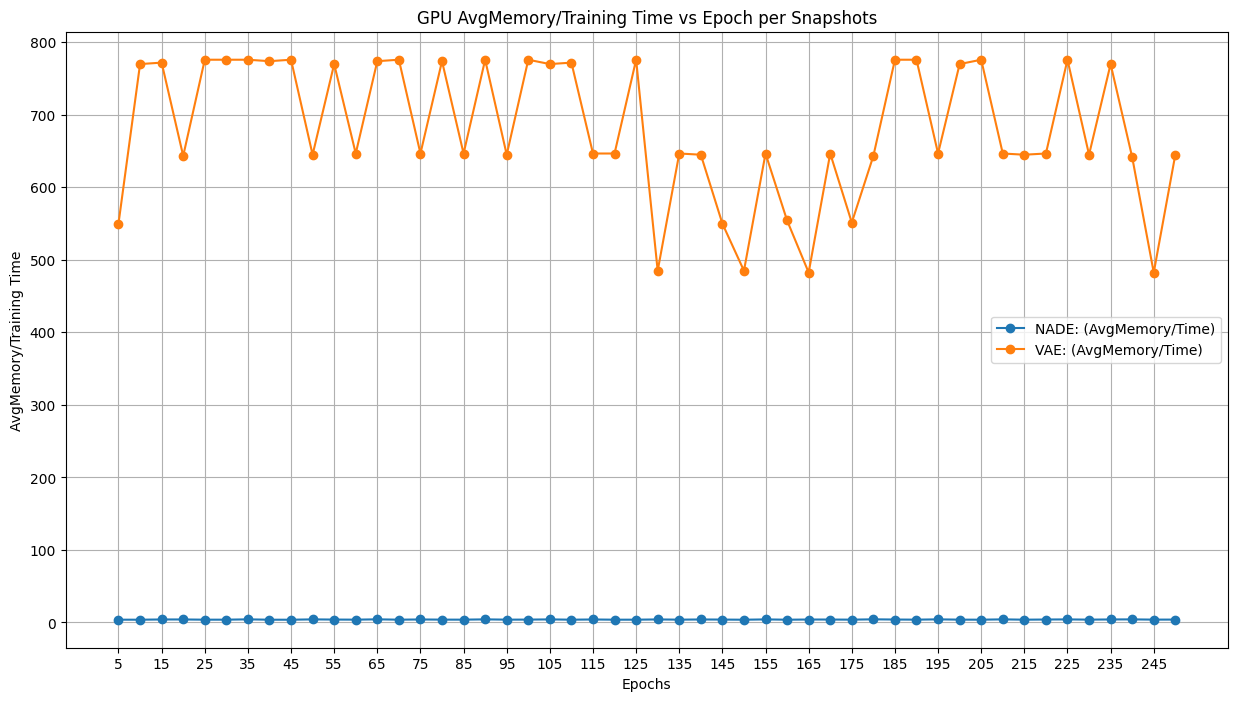

In [ ]:

# Plot (Average GPU Memory/Training Time) vs epoch
plt.figure(figsize=(15,8))

plt.plot( nade_log['epoch'], nade_log['avg_mem_MB']/nade_log['elapsed_time_s'], 'o-',label="NADE: (AvgMemory/Time)")
plt.plot( vae_log['epoch'], vae_log['avg_mem_MB']/vae_log['elapsed_time_s'], 'o-',label="VAE: (AvgMemory/Time)")

plt.xticks(np.arange(5, 255, 10))
plt.xlabel('Epochs')
plt.ylabel('AvgMemory/Training Time')
plt.title('GPU AvgMemory/Training Time vs Epoch per Snapshots')

plt.legend()
plt.grid()
plt.show()


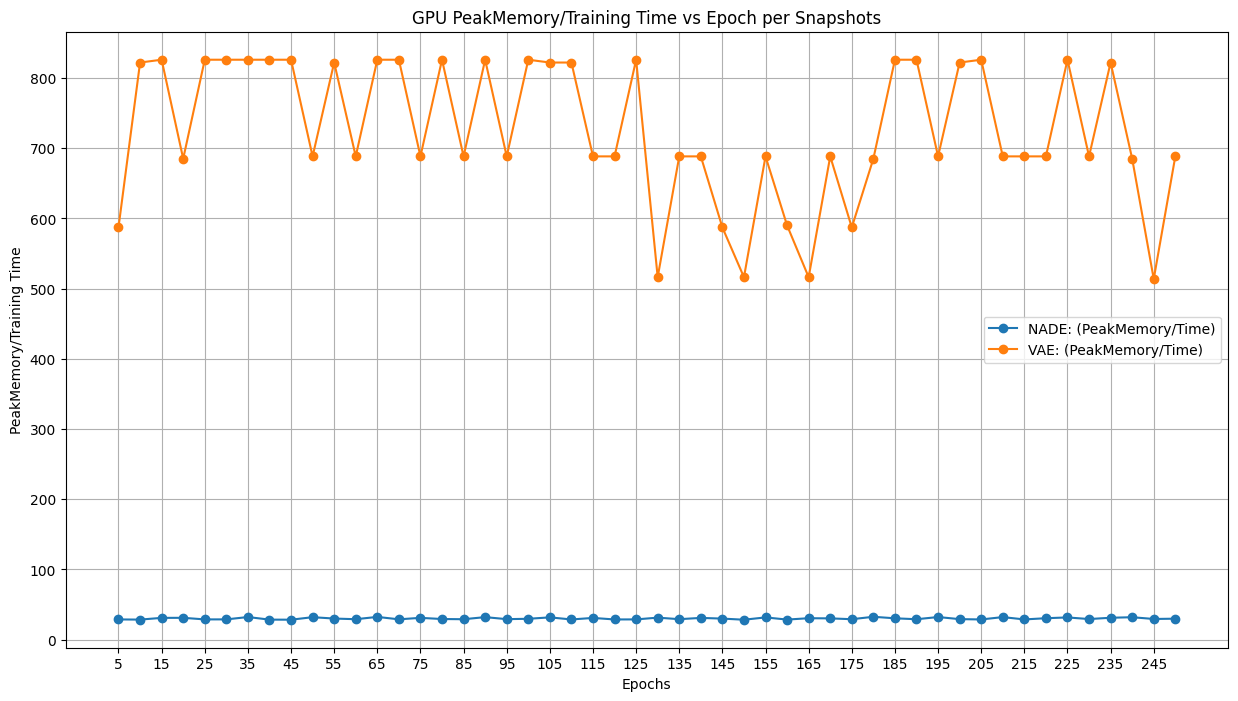

In [ ]:

# Plot (Peak GPU Memory/Training Time) vs epoch
plt.figure(figsize=(15,8))

plt.plot( nade_log['epoch'], nade_log['peak_mem_MB']/nade_log['elapsed_time_s'], 'o-',label="NADE: (PeakMemory/Time)")
plt.plot( vae_log['epoch'], vae_log['peak_mem_MB']/vae_log['elapsed_time_s'], 'o-',label="VAE: (PeakMemory/Time)")

plt.xticks(np.arange(5, 255, 10))
plt.xlabel('Epochs')
plt.ylabel('PeakMemory/Training Time')
plt.title('GPU PeakMemory/Training Time vs Epoch per Snapshots')

plt.legend()
plt.grid()
plt.show()


## - At what point does VAE converge vs. NADE?
<div dir='rtl' align='justify'>
از نمودار FID vs Epochs به نظر می‌رسد VAE در حدود ایپاک ۱۵۰ همگرا میشود و مقدار  FID آن تقریبا ثابت میماند و ایپاک های اضافی بهبود زیادی رو ایجاد نمیکند در حالی که زمان و حافظه مصرفی GPU  تقریبا همان قدر باقی میماند. در حالی که NADE همچنان به تدریج FID مدل NADE تا ایپاک 205 کاهش پیدا میکند و بعد از  آن تقریبا ثابت میماند. در نهایت با وجود اینکه تا ایپاک بالایی آموزش دیده نمیتواند از مدل VAE بهتر عمل کند و هر بهبود جزئی نیاز به انجام کامل محاسبات دنباله ای مدل دارد و که هزینه محاسباتی بالایی دارد.
</div>

## - Is more training always better?

<div dir='rtl' align='justify'>
ادامه دادن آموزش بعد از نقطه همگرایی با وجود مصرف منابع تقریبا برابر، باعث بهبودهای کوچکی میشود. در مورد VAE، حتی ممکن است آموزش بیش از حد باعث بیش برازشی شود و نمونه ها دقیقا مشابه داده آموزشی باشند. در NADE هم با وجود اینکه کاهش FID ادامه دارد، اما هر واحد بهبود نیازمند صرف هزینه محاسباتی قابل توجهی است. بنابراین برای جلوگیری از هدر رفتن منابع (مثل زمان GPU) و کاهش ریسک بیش‌برازش، بهتر است از تکنیک early stopping مبتنی بر معیار اعتبارسنجی مثل FID  استفاده کنیم. به طوریکه آموزش مدل زمانی متوقف شود که میزان بهبود در هر اپک از یک آستانه مشخص کمتر شود.

</div>


# **Task 7: Sampling Speed**

## - Time how long each model takes to generate:

In [ ]:
import time

Time for 1 sample

In [ ]:
# Time for generate one sample using NADE
start_time = time.time()
one_sample = NADE_model.generate_samples(1).cpu().numpy() # generate 1 sample using NADE
Time_one_smple_nade = time.time() - start_time

print(f"It takes: {Time_one_smple_nade:.4f} seconds to generate 1 sample with NADE")

# Time for generate one sample using VAE
start_time = time.time()
# generate 1 sample using VAE
z_1 = torch.randn(1, VAE_model.encoder.mu.out_features).to(device)
one_sample = VAE_model.decoder(z_1).cpu()
Time_one_smple_vae = time.time() - start_time

print(f"It takes {Time_one_smple_vae:.4f} seconds to generate 1 sample with VAE ")

It takes: 92.5396 seconds to generate 1 sample with NADE
It takes 0.0009 seconds to generate 1 sample with VAE 


Time for 100 samples

In [ ]:
# Time for generate 100 sample using NADE
start_time = time.time()
hundred_sample = NADE_model.generate_samples(100).cpu().numpy() # generate 100 sample using NADE
Time_hundred_smple_nade = time.time() - start_time

print(f"It takes: {Time_hundred_smple_nade:.4f} seconds to generate 100 sample with NADE")

# Time for generate 100 sample using VAE
start_time = time.time()
# generate 100 sample using VAE
z_100 = torch.randn(100, VAE_model.encoder.mu.out_features).to(device)
hundred_sample = VAE_model.decoder(z_100).cpu()
Time_hundred_smple_vae = time.time() - start_time

print(f"It takes {Time_hundred_smple_vae:.4f} seconds to generate 100 samples with VAE ")

It takes: 91.6407 seconds to generate 100 sample with NADE
It takes 0.0012 seconds to generate 100 samples with VAE 


## - Why is NADE slower?
<div dir='rtl' align='justify'>
مدل NADE یک مدل Autoregressive است که توزیع داده ها را به صورت حاصل ضرب توزیع های شرطی مدل میکند و پیکسل ها را به صورت دنباله ای تولید می کند. یعنی تا وقتی پیکسل قبلی تولید نشده، تولید پیکسل بعدی ممکن نیست. در نتیجه، برخلاف VAE که می تواند همه ابعاد را به صورت موازی نمونه برداری کند، NADE برای هر یک از D بعد داده باید یک forward pass از شبکه انجام دهد و این کار D بار تکرار می شود،بنابراین تولید نمونه در NADE بسیار کند تر است.

</div>

## - Could caching improve its speed?
<div dir='rtl' align='justify'>
در NADE هر پیکسل به صورت ترتیبی و وابسته به تمام پیکسل های قبلی تولید میشود، بنابراین در هر گام برای پیشبینی یک پیکسل جدید همه محاسبات لایه پنهان دوباره اجرا می‌گردد، حتی اگر تنها یک ورودی جدید اضافه شده باشد. اگر خروجی های لایه پنهان را ذخیره کنیم، دیگر نیازی به تکرار آن بخش از محاسبات نیست و تنها بخش مربوط به ورودی تازه پردازش میشود. بنابراین caching  اجرای مجدد محاسبات مشابه را حذف کرده و سرعت تولید نمونه ها را به طور چشمگیری افزایش میدهد
</div>



# **Task 9: Limitations & Ethics**
##- If NADE has better FID but VAE trains faster which would you deploy on a mobile device?

<div dir='rtl' align='justify'>
در پیاده سازی و استفاده یک مدل مولد روی موبایل، کارایی و سرعت اجرای حین تولید نمونه و استنباط و آموزش مدل خیلی مهم تر است تا دقت و کیفیت نمونه ها. چون موبایل ها نسبت به دستگاهای پردازشی دیگر تجهیزاتشان مانند GPU یا CPU و باتری ضعیف تر است و حافظه رم و ذخیره سازی کمتری دارند. ویژگی های یک مدل مناسب روی موبایل، تولید نمونه و استنباط و آموزش مدل با سرعت بالا و مصرف کم حافظه است. FID بهتر NADE باعث تولید نمونه های واضح تر میشود اما اینکه تولید نمونه های آن Autoregressive و به صورت پیکسل به پیکسل است، در زمان اجرا هزینه انرژی و حافظه بالایی میشود و سرعت اجرای آن بسیار کند است چون امکان موازی سازی محاسبات در NADE وجود ندارد. در مقابل VAE میتواند کل تصویر را در یک forward pass از طریق decoder تولید کند که باعث میشود روی دستگاه بسیار سریع تر و بهینه تر از نظر مصرف انرژی و حافظه باشد. بنابراین با وجود FID متوسط تر مدل VAE به دلیل سرعت بالای آن برای برنامه های موبایل کاربردی تر است.
</div>

##- MNIST is grayscale and low-res—how might FID/KID mislead us on CIFAR-10?

<div dir='rtl' align='justify'>
برای CIFAR-10 که تصاویرش رنگی است و پیچیدگی و تنوع بیشتری نسبت به MNIST دارد، FID و KID میتونند خیلی گمراه کننده باشند:

این دو معیار فقط میانگین و واریانسِ ویژگی ها رو در نظر می‌گیرند. در نتیجه ممکنه مدل توزیع آماری را درست منتقل کند ولی مثلا رنگ ها را به کل اشتباه بزند مثلا سگی با رنگ صورتی یا اجسام را وارونه تولید کند. FID/KID پایین میاید بدون اینکه نمونه های تولید شده خوب باشند.

FID و KID شکل هندسی و منطق ساختاری  و معنای تصویر را متوجه نمیشوند. مثلا چینش اجرا درست نباشه مثلا سگی تولید کند که 5 پا دارد ولی بافت و رنگ سگ را دارد. با این حال ممکن است FID و KID خوب باشند ولی این استباه است.

CIFAR-10 ده کلاس متفاوت دارد، ولی FID/KID میانگین کل ویژگی ها را می‌سنجند. پس اگر مدل فقط چند کلاس را خوب یاد گرفته باشد و بقیه را در نظر نگرفته باشد، باز هم نمره پایینی میگیرد و FID و KID پایین بیایند در حالی که مدل اصلا متنوع و خوب نیست.

در مجموع برای مجموعه هایی مثل CIFAR-10 که رنگ، شکل، بافت و کلاس های متنوعی دارد، FID و KID تنها بخش کوچیکی از کیفیت رو می‌سنجند و نباید به تنهایی بهشون اعتماد کرد
</div>

##- Could either model’s latent space leak private training data?

<div dir='rtl' align='justify'>
از آنجا که NADE یک مدل Autoregressive است، متغیر پنهان مشخصی ندارد و هر پیکسل خروجی فقط به پارامترهای مدل و پیکسل های قبلی وابسته است. اگر مدل بیش ازحد روی داده های آموزش بیش برازش شود، ممکن است برخی نمونه ها را در پارامترهایش حفظ کند، اما هیچ کد پنهان مستقیمی وجود ندارد که بتوان آن را برگرداند و داده‌های اصلی را استخراج کرد.

برخلاف NADE، مدل VAE ورودی ها را به یک فضای پنهان پیوسته میبرد. در نتیجه ممکن است ویژگی های خاص نمونه های آموزشی در این فضای پنهان ذخیره شوند. کسی که به بخشی از انکودر یا خروجی‌های آن دسترسی داشته باشد، با کمی آزمون و خطا یا بهینه سازی میتواند نقاطی پیدا کند که تصویر اصلی را دوباره تولید کند و نمونه‌های آموزش را بازسازی یا استنباط کند.


</div>